In [14]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from tqdm import tqdm
import os

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from model.old_models.arima import prepare_series, select_order, fit_arima, forecast as arima_forecast
from model.old_models.exp_smoothing import fit_ets, forecast as ets_forecast

TEST_YEARS = 5
MIN_TRAIN_POINTS = 10

pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", message="Matrix is singular")

In [4]:
def _metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    errors = predicted - actual
    return {"mae": np.mean(np.abs(errors)), "rmse": np.sqrt(np.mean(errors ** 2))}

In [5]:
def backtest_all_indicators(df, indicators, test_years=TEST_YEARS):
    rows = []
    countries = sorted(df["Country"].unique())
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i, country in enumerate(countries):
            if i % 10 == 0:
                print(f"Processing country {i + 1}/{len(countries)}: {country}", file=sys.__stdout__)
            for indicator in indicators:
                try:
                    series = prepare_series(df, country, indicator)
                except ValueError:
                    continue
                if len(series) < MIN_TRAIN_POINTS + test_years:
                    continue

                train, test = series.iloc[:-test_years], series.iloc[-test_years:]

                try:
                    order = select_order(train)
                    pred = arima_forecast(fit_arima(train, order=order), steps=test_years)
                    m = _metrics(test.values, pred["forecast"].values)
                    rows.append({"country": country, "indicator": indicator, "model": "arima", **m, "error": None})
                except Exception as exc:
                    rows.append({"country": country, "indicator": indicator, "model": "arima", "mae": None, "rmse": None, "error": str(exc)})

                try:
                    pred = ets_forecast(fit_ets(train), steps=test_years)
                    m = _metrics(test.values, pred["forecast"].values)
                    rows.append({"country": country, "indicator": indicator, "model": "ets", **m, "error": None})
                except Exception as exc:
                    rows.append({"country": country, "indicator": indicator, "model": "ets", "mae": None, "rmse": None, "error": str(exc)})

    return pd.DataFrame(rows)

## Run backtest

Reads `processed_data.csv` directly ...no dependency on `compute_composite_risk`/`get_composite_risk`. Note: this is only the 12 raw ND-GAIN sub-indicators; `Readiness`/`Vulnerability`/`CompositeRisk` are derived columns, not present in the raw preprocessed data, so they're excluded here for a clean, apples-to-apples comparison.

**This will take a while**

In [7]:
indicators = ["Capacity", "Economic", "Ecosystems", "Exposure", "Food", "Governance",
              "Habitat", "Health", "Infrastructure", "Sensitivity", "Social", "Water"]

df = pd.read_csv(ROOT / "data" / "data_preprocessed" / "processed_data.csv")

import contextlib
import io

buffer = io.StringIO()
with contextlib.redirect_stdout(buffer), contextlib.redirect_stderr(buffer):
    results = backtest_all_indicators(df, indicators)

captured_output = buffer.getvalue()
print(f"Convergence fallbacks: {captured_output.count('did not converge')}")
results.head()

Processing country 1/186: AFG
Processing country 11/186: BDI
Processing country 21/186: BLZ
Processing country 31/186: CHL
Processing country 41/186: CUB
Processing country 51/186: EGY
Processing country 61/186: GBR
Processing country 71/186: GUY
Processing country 81/186: ISL
Processing country 91/186: KIR
Processing country 101/186: LSO
Processing country 111/186: MKD
Processing country 121/186: MYS
Processing country 131/186: PAK
Processing country 141/186: QAT
Processing country 151/186: SLV
Processing country 161/186: SYR
Processing country 171/186: TUR
Processing country 181/186: VUT
Convergence fallbacks: 628


,country,indicator,model,mae,rmse,error
0,AFG,Capacity,arima,0.0407,0.0408,None
1,AFG,Capacity,ets,0.0168,0.0183,None
2,AFG,Economic,arima,0.0149,0.0162,None
3,AFG,Economic,ets,0.0429,0.0454,None
4,AFG,Ecosystems,arima,0.0011,0.0012,None


## Results

In [7]:
valid = results[results["error"].isna()]
print("Overall by model:")
valid.groupby("model")[["mae", "rmse"]].agg(["mean", "median"])

Overall by model:


mae                rmse          
           mean    median      mean    median
model                                        
arima  0.015387  0.007475  0.016826  0.008419
ets    0.014360  0.006216  0.015940  0.007153

In [8]:
print("Head-to-head win rate (lower MAE wins), per (country, indicator):")
pivot = valid.pivot_table(index=["country", "indicator"], columns="model", values="mae").dropna()
winner = np.where(pivot["arima"] < pivot["ets"], "arima", np.where(pivot["arima"] > pivot["ets"], "ets", "tie"))
pd.Series(winner).value_counts()

Head-to-head win rate (lower MAE wins), per (country, indicator):


ets      1300
arima     911
tie        21
Name: count, dtype: int64

In [24]:
print("By indicator (mean MAE per model):")
by_indicator = valid.groupby(["indicator", "model"])["mae"].mean().unstack()

def highlight_winner(row):
    winner = row.idxmin()  # lower MAE wins
    return ["background-color: lightgreen" if col == winner else "" for col in row.index]

by_indicator.style.apply(highlight_winner, axis=1).format("{:.6f}")

By indicator (mean MAE per model):


model,arima,ets
indicator,,
Capacity,0.018352,0.016503
Economic,0.028195,0.025280
Ecosystems,0.003156,0.002960
Exposure,0.000004,0.000000
Food,0.010863,0.010622
Governance,0.036163,0.032891
Habitat,0.007861,0.009131
Health,0.015548,0.016697
Infrastructure,0.032868,0.031134


In [10]:
n_failed = results["error"].notna().sum()
print(f"Failed fits: {n_failed} / {len(results)}")
if n_failed:
    results[results["error"].notna()][["country", "indicator", "model", "error"]].head(20)

Failed fits: 0 / 4464


In [27]:
arima_df = pd.read_csv(ROOT / "data" / "outputs" / "all_indicators_with_forecast.csv")
ets_df = pd.read_csv(ROOT / "data" / "outputs" / "all_indicators_ets_forecast.csv")
arima2_df = pd.read_csv(ROOT / "data" / "outputs" / "all_indicator_values.csv")

arima_avg = arima_df.groupby(["year", "indicator"])["value"].mean().unstack()
ets_avg = ets_df.groupby(["year", "indicator"])["value"].mean().unstack()
arima2_avg = arima2_df.groupby(["year", "indicator"])["value"].mean().unstack()

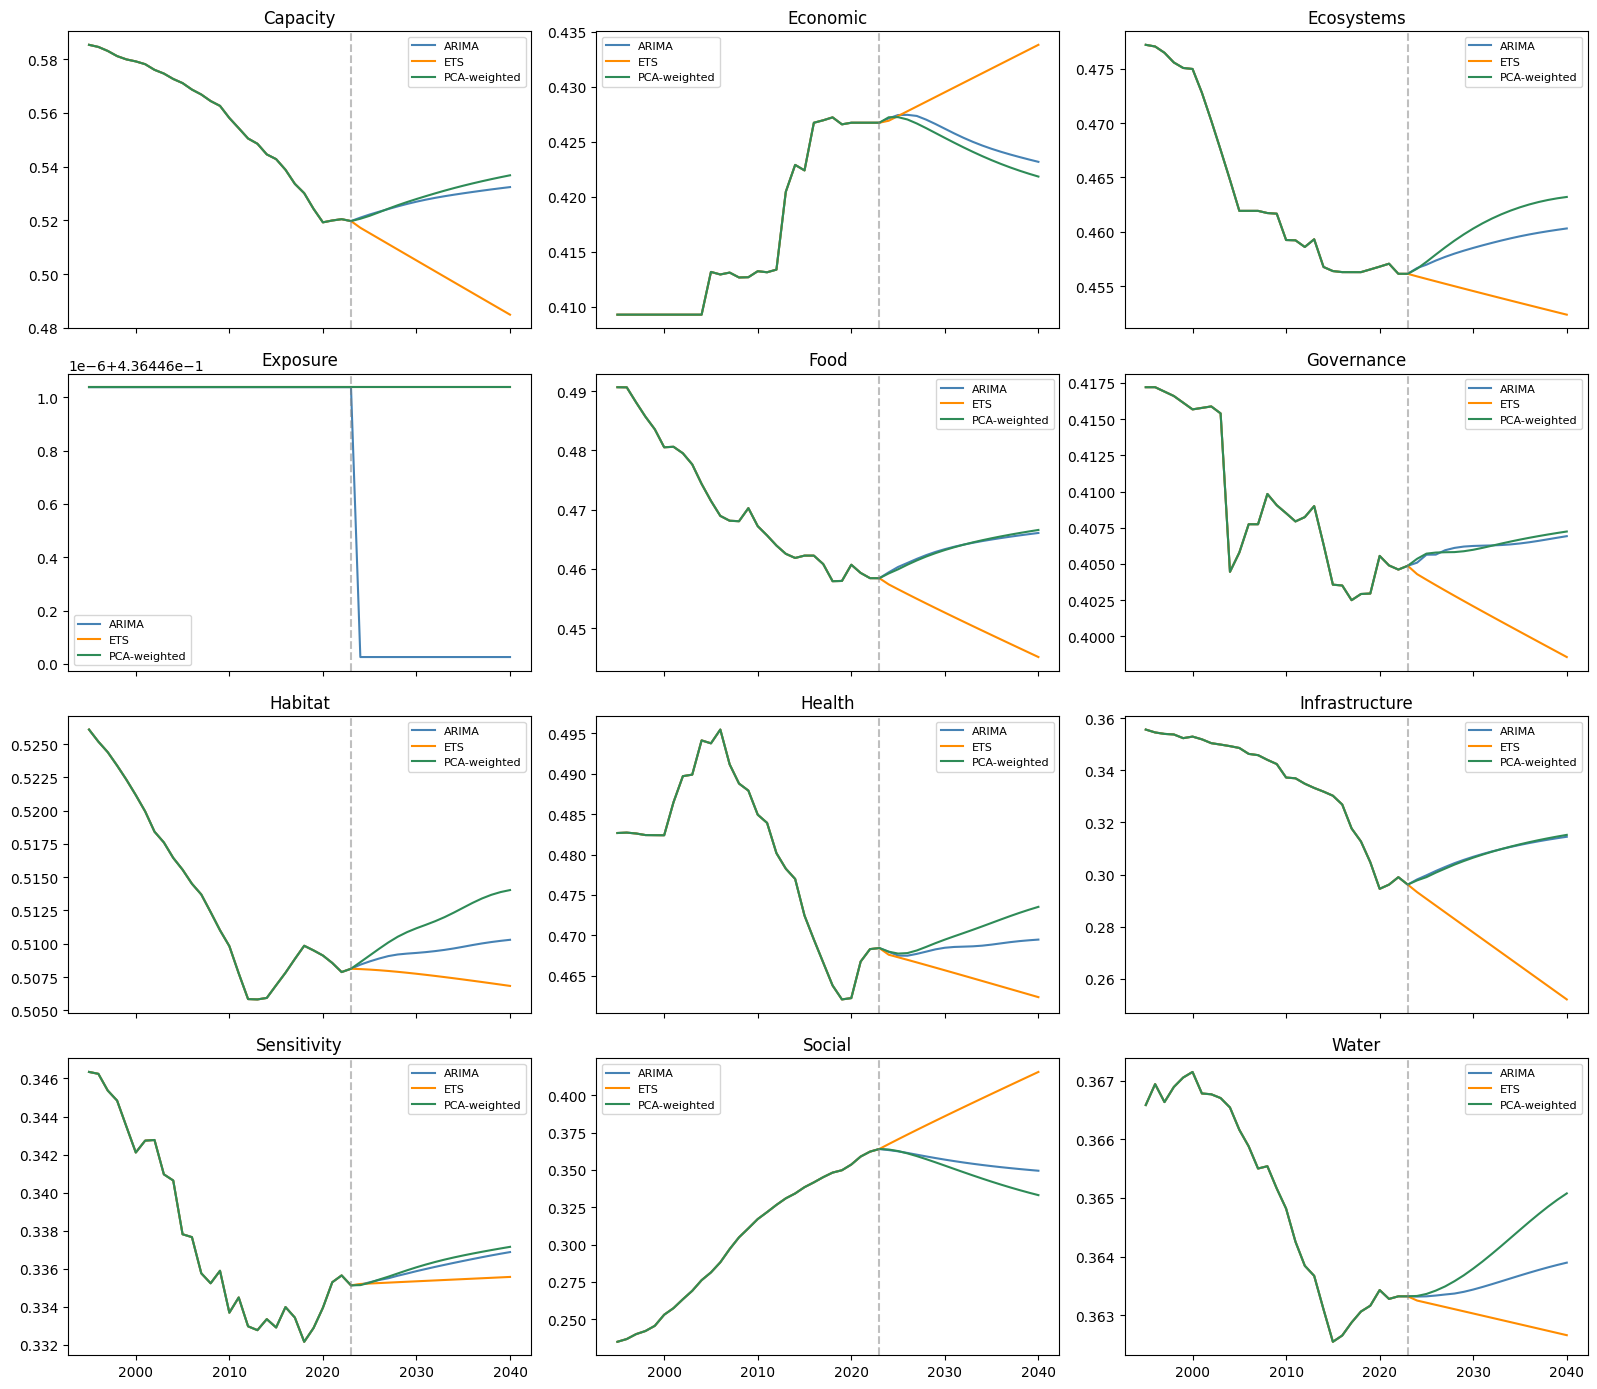

In [29]:
indicators = ["Capacity", "Economic", "Ecosystems", "Exposure", "Food", "Governance",
              "Habitat", "Health", "Infrastructure", "Sensitivity", "Social", "Water"]

fig, axes = plt.subplots(4, 3, figsize=(16, 14), sharex=True)
axes = axes.flatten()

for i, indicator in enumerate(indicators):
    ax = axes[i]
    if indicator in arima_avg.columns:
        ax.plot(arima_avg.index, arima_avg[indicator], label="ARIMA", color="steelblue")
    if indicator in ets_avg.columns:
        ax.plot(ets_avg.index, ets_avg[indicator], label="ETS", color="darkorange")
    if indicator in arima2_avg.columns:
        ax.plot(arima2_avg.index, arima2_avg[indicator], label="PCA-weighted", color="seagreen")
    ax.axvline(x=2023, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(indicator)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Third comparison: shared-order-per-indicator ARIMA (second_arima.py)

Different methodology from the per-country ARIMA above: instead of a
bespoke (p, d, q) order per (country, indicator), this picks ONE order per
indicator (lowest average AIC across all countries) and reuses it for
every country. Also does not forecast Exposure, Readiness, or
Vulnerability at all.

In [ ]:
import sys
sys.path.insert(0, str(ROOT))  # ROOT already defined earlier in your notebook

from model.second_arima.second_arima import ARIMACountryModel, load_data

In [33]:
TEST_YEARS = 5

df_original = pd.read_csv(ROOT / "data" / "data_preprocessed" / "processed_data.csv").set_index(["Country", "Year"])
df = df_original.drop(columns=["Exposure", "Readiness", "Vulnerability"])

df_reset = df.reset_index()
last_years = df_reset.groupby("Country")["Year"].transform("max")
train_mask = df_reset["Year"] <= (last_years - TEST_YEARS)
test_mask = df_reset["Year"] > (last_years - TEST_YEARS)

df_train = df_reset[train_mask].set_index(["Country", "Year"])
df_test = df_reset[test_mask].set_index(["Country", "Year"])

countries = df_train.index.get_level_values("Country").unique()
indicators = df_train.columns

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model = ARIMACountryModel()
    model.fit(df_train, countries, indicators)
    forecasts = model.forecast(years=TEST_YEARS)

TRAINING ARIMA MODELS - STRATEGY: 1 ORDER PER INDICATOR
Step 1: Selecting best order for each indicator...
✓ Selected orders:
  Capacity: (2, 0, 0)
  Economic: (2, 0, 0)
  Ecosystems: (2, 0, 0)
  Food: (2, 0, 0)
  Governance: (2, 0, 0)
  Habitat: (2, 0, 1)
  Health: (2, 0, 0)
  Infrastructure: (2, 0, 0)
  Sensitivity: (2, 0, 0)
  Social: (2, 0, 0)
  Water: (2, 0, 0)
Step 2: Fitting final models on full data...
<class 'pandas.core.series.Series'>
Capacity
Index([1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
      dtype='int64', name='Year')
  [2/2232] AFG                  - Capacity                       | AIC:    -132.86 | MSE:   0.000487
<class 'pandas.core.series.Series'>
Economic
Index([1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
      dtype='int64', name='Year')
  [3/2232

In [35]:
print(len(forecasts))
print(list(forecasts.keys())[:5])

first_country = list(forecasts.keys())[0]
print(forecasts[first_country].keys())

186
['AFG', 'AGO', 'ALB', 'ARE', 'ARG']
dict_keys(['Capacity', 'Economic', 'Ecosystems', 'Food', 'Governance', 'Habitat', 'Health', 'Infrastructure', 'Sensitivity', 'Social', 'Water'])


In [36]:
country = "AFG"
indicator = "Capacity"

actual = df_test.loc[country, indicator]
predicted = forecasts[country][indicator]

print(type(actual), actual)
print(type(predicted), predicted)

<class 'pandas.core.series.Series'> Year
2019   0.6652
2020   0.6643
2021   0.6632
2022   0.6736
2023   0.6736
Name: Capacity, dtype: float64
<class 'pandas.core.series.Series'> 24   0.7064
25   0.7075
26   0.7087
27   0.7099
28   0.7111
Name: predicted_mean, dtype: float64


In [37]:
rows = []
for country in forecasts:
    for indicator in forecasts[country]:
        try:
            actual = df_test.loc[country, indicator].sort_index()
            predicted = forecasts[country][indicator]

            n = min(len(actual), len(predicted))
            if n == 0:
                continue

            errors = predicted.values[:n] - actual.values[:n]
            rows.append({
                "country": country, "indicator": indicator, "model": "arima_shared_order",
                "mae": np.mean(np.abs(errors)), "rmse": np.sqrt(np.mean(errors ** 2)), "error": None,
            })
        except Exception as exc:
            rows.append({"country": country, "indicator": indicator, "model": "arima_shared_order",
                         "mae": None, "rmse": None, "error": str(exc)})

results_v2 = pd.DataFrame(rows)
valid_v2 = results_v2[results_v2["error"].isna()]
valid_v2.groupby("indicator")[["mae", "rmse"]].mean()

,mae,rmse
indicator,,
Capacity,0.0182,0.0196
Economic,0.0274,0.0292
Ecosystems,0.0036,0.0042
Food,0.0109,0.0121
Governance,0.0351,0.0390
Habitat,0.0081,0.0089
Health,0.0148,0.0168
Infrastructure,0.0332,0.0357
Sensitivity,0.0090,0.0102


In [38]:
combined_valid = pd.concat([valid[["country", "indicator", "model", "mae", "rmse"]], valid_v2], ignore_index=True)

by_indicator_combined = combined_valid.groupby(["indicator", "model"])["mae"].mean().unstack()

def highlight_winner(row):
    winner = row.idxmin()
    return ["background-color: lightgreen" if col == winner else "" for col in row.index]

by_indicator_combined.style.apply(highlight_winner, axis=1).format("{:.6f}")

model,arima,arima_shared_order,ets
indicator,,,
Capacity,0.018352,0.018205,0.016503
Economic,0.028195,0.027403,0.025280
Ecosystems,0.003156,0.003632,0.002960
Exposure,0.000004,nan,0.000000
Food,0.010863,0.010859,0.010622
Governance,0.036163,0.035122,0.032891
Habitat,0.007861,0.008111,0.009131
Health,0.015548,0.014825,0.016697
Infrastructure,0.032868,0.033174,0.031134


In [10]:
df = pd.read_csv("../data/outputs/all_indicator_values.csv")

In [ ]:
df_dropped = df.drop(

KeyError: "['CompositeRisk', 'Readiness', 'Vulnerability'] not found in axis"

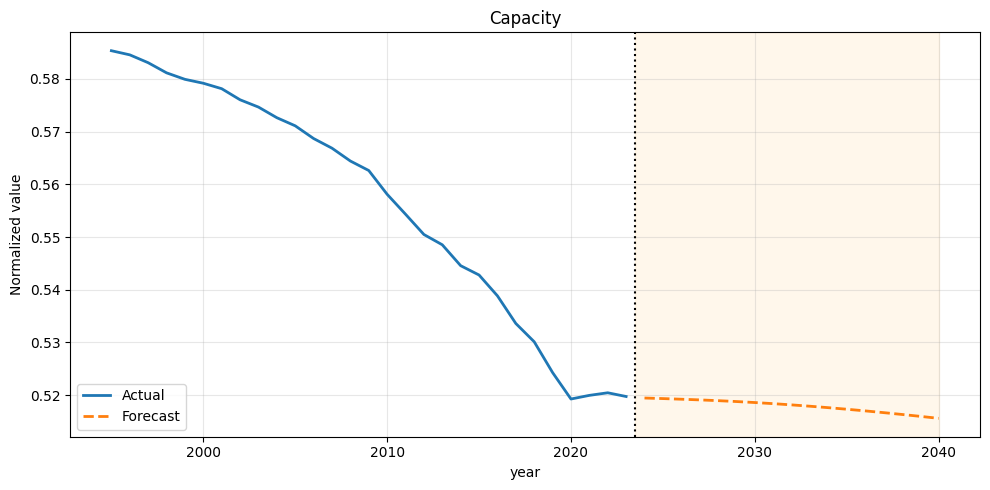

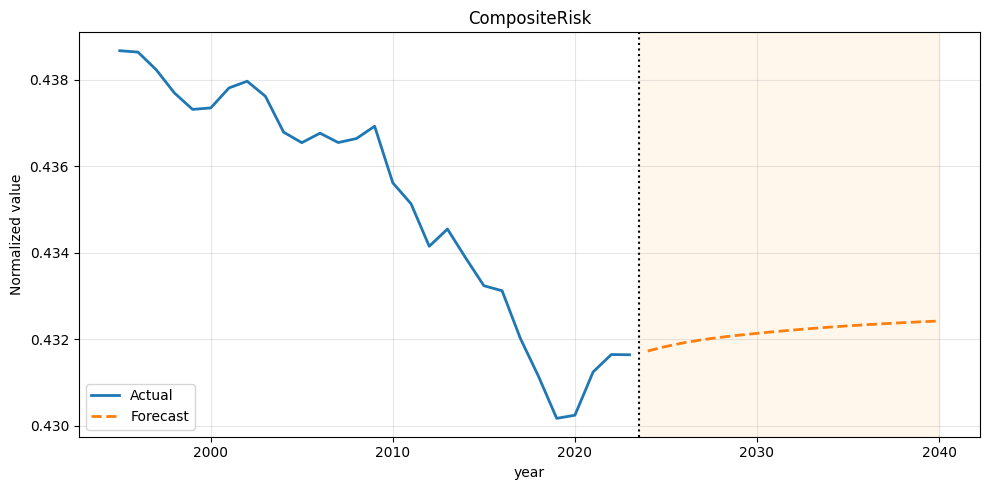

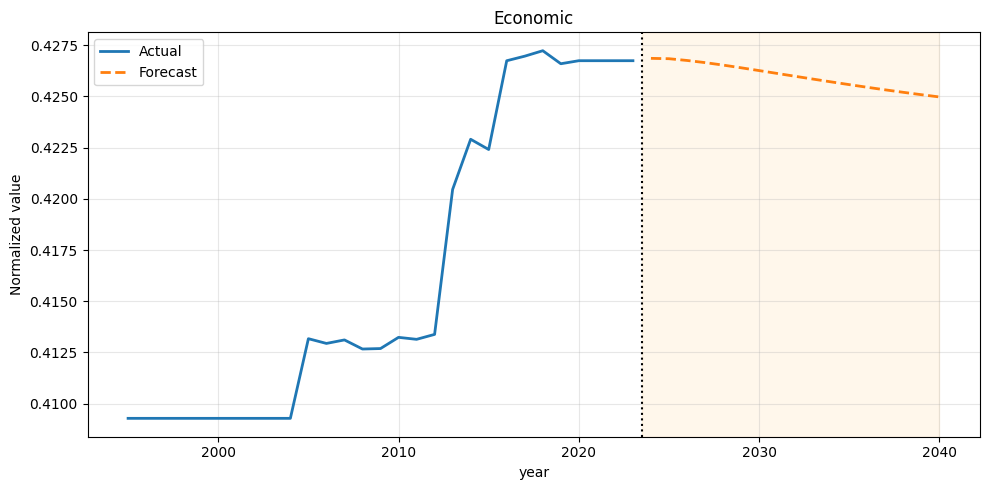

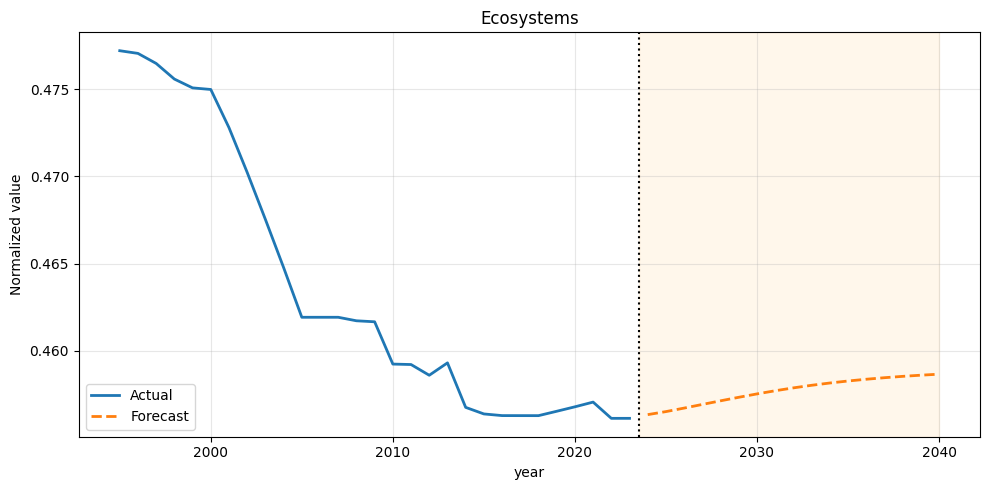

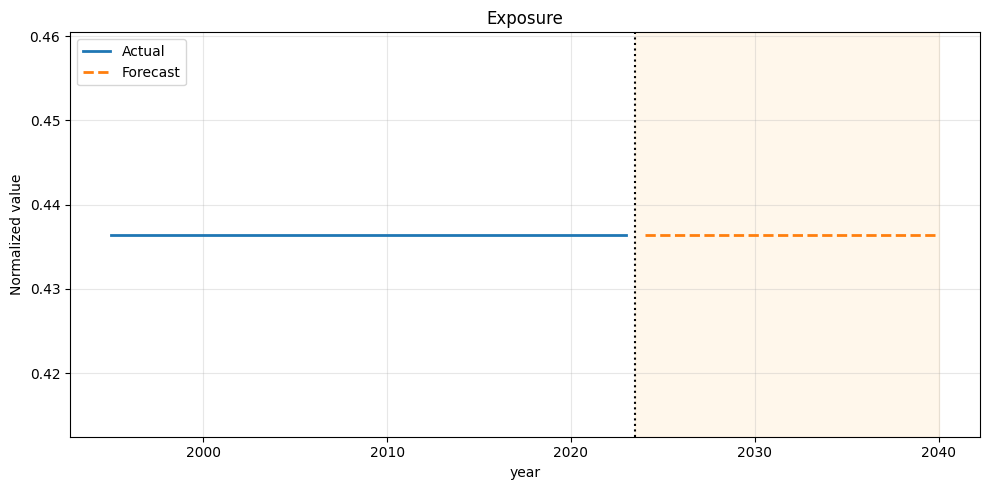

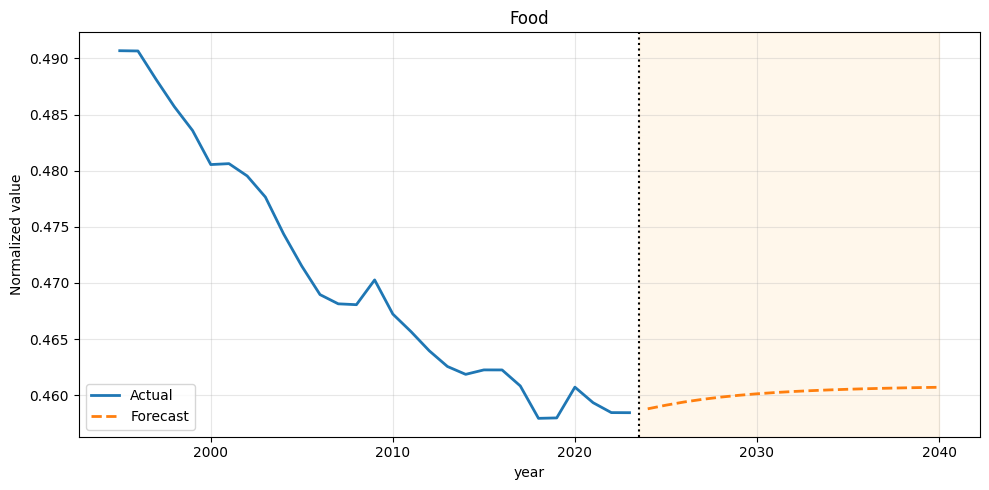

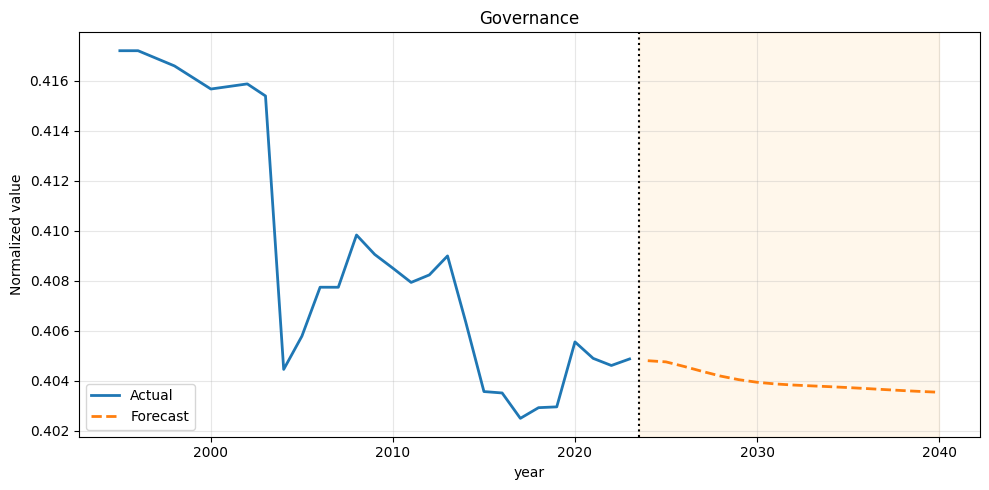

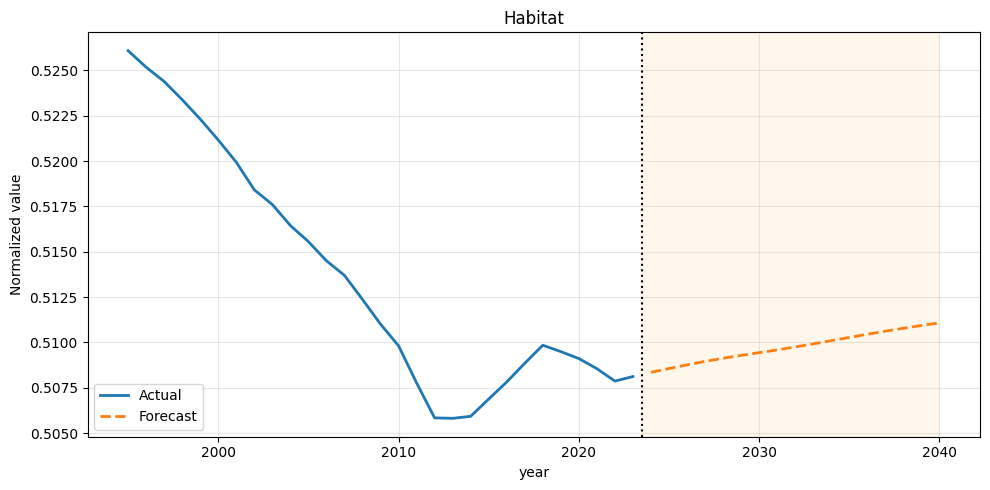

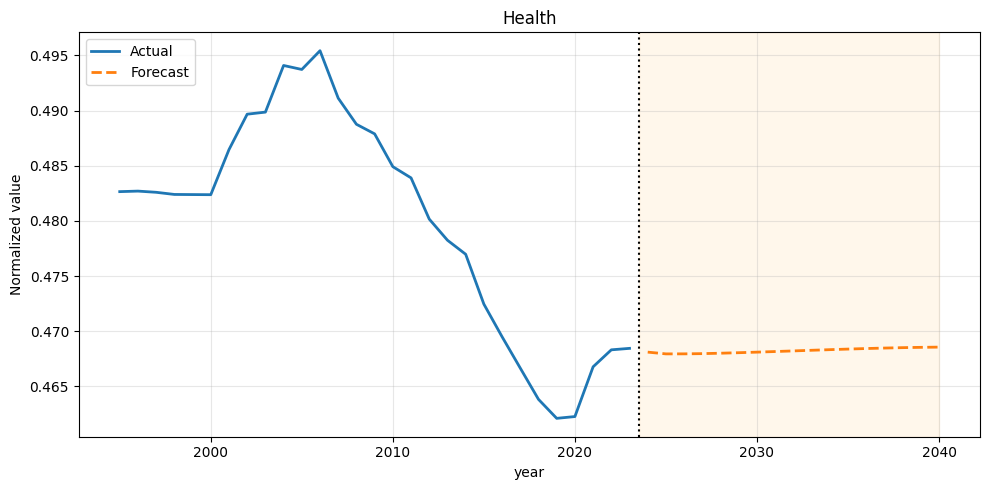

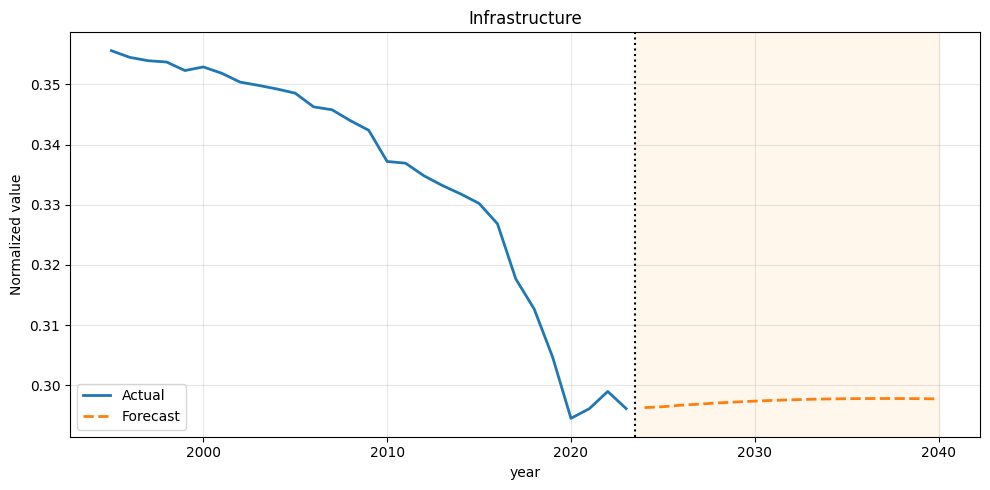

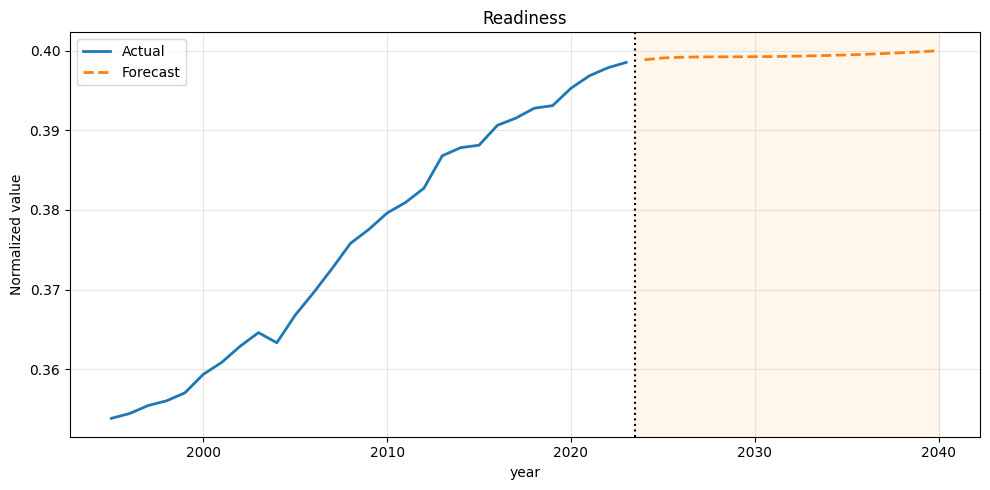

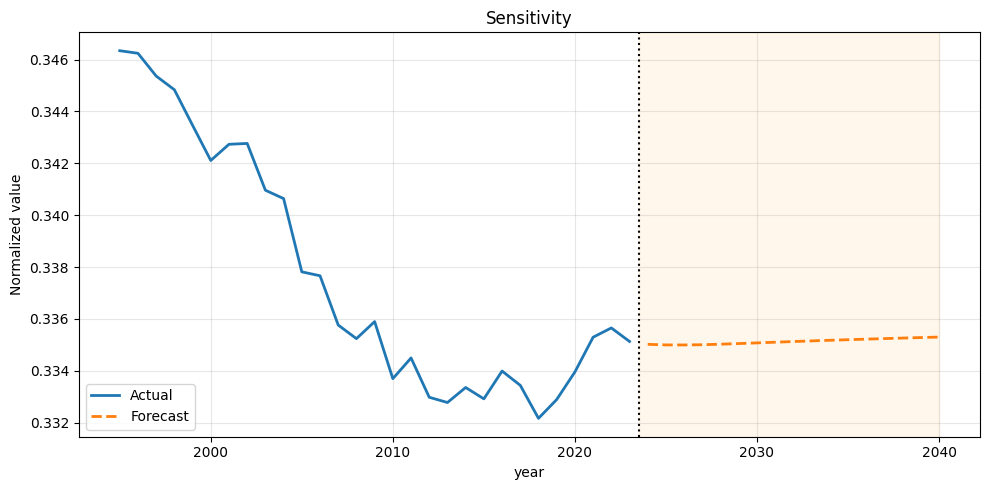

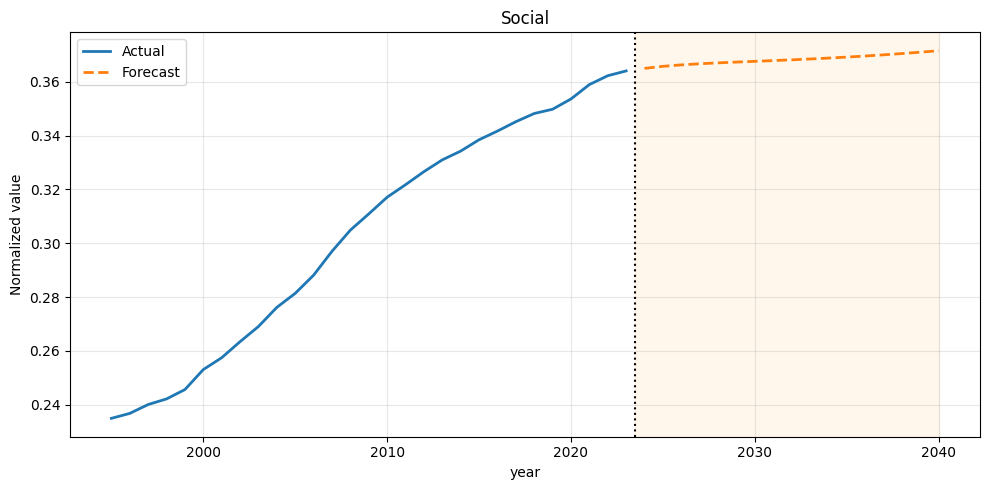

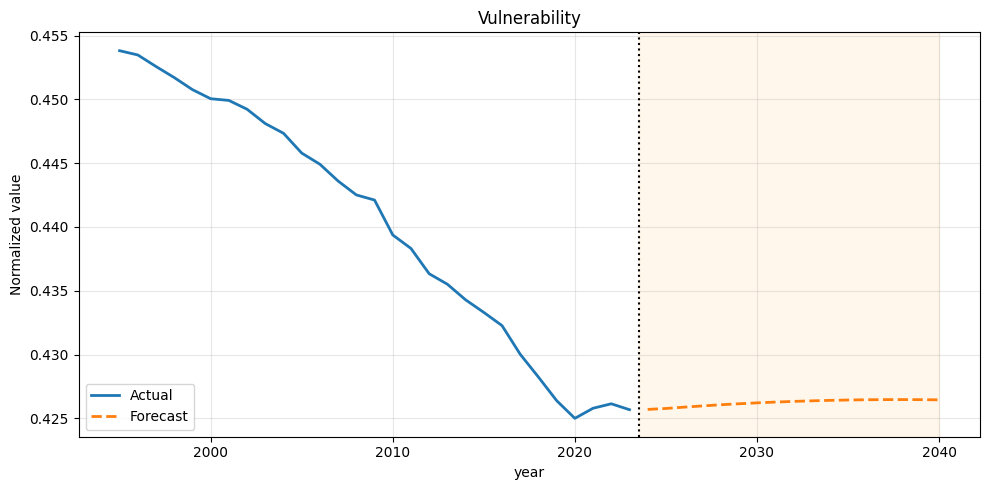

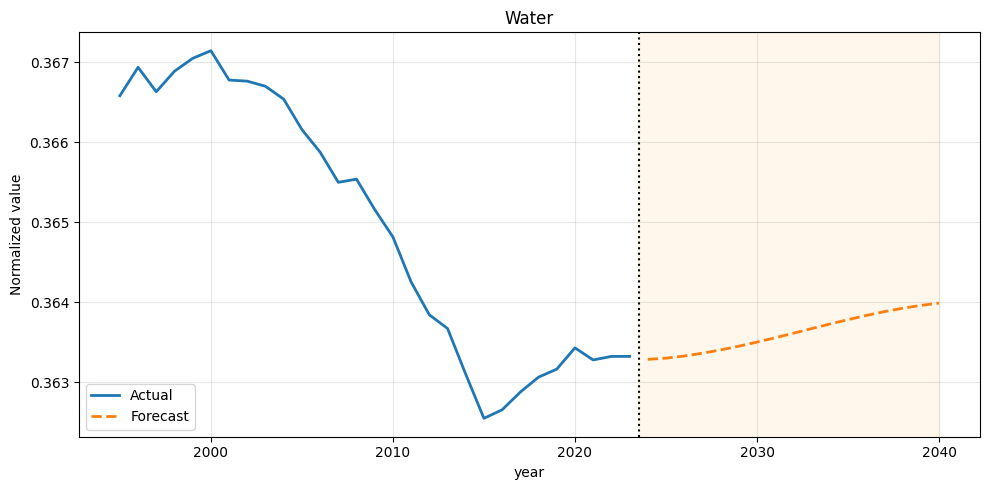

In [ ]:
actual_end = 2023

for indicator in sorted(df["indicator"].unique()):

    df_plot = (
        df[df["indicator"] == indicator]
        .groupby("year", as_index=False)["value"]
        .mean()      # average across countries
    )

    actual = df_plot[df_plot["year"] <= actual_end]
    forecast = df_plot[df_plot["year"] > actual_end]

    plt.figure(figsize=(10,5))

    # Actual values
    plt.plot(
        actual["year"],
        actual["value"],
        color="tab:blue",
        linewidth=2,
        label="Actual"
    )

    # Forecast
    plt.plot(
        forecast["year"],
        forecast["value"],
        color="tab:orange",
        linewidth=2,
        linestyle="--",
        label="Forecast"
    )

    # Separator
    plt.axvline(
        x=2023.5,
        color="black",
        linestyle=":",
        linewidth=1.5
    )

    # Optional forecast shading
    plt.axvspan(
        2023.5,
        df["year"].max(),
        color="orange",
        alpha=0.08
    )

    plt.title(indicator)
    plt.xlabel("year")
    plt.ylabel("Normalized value")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()